# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [31]:
corpus = '''

Hi, myself Kalpana Baghel. My life is full of chaos, drama, and enthusiasm. I
enjoy every moment and I cannot stay sad for a long time. By the way, I am an
engineering student at JK Lakshmipat University (JKLU), but that is not the
saddest part. The saddest part is that I know how much potential I have, but I
am not able to use it fully. This thought often makes me feel worse.

If I had to describe myself using a machine learning concept, I would definitely
say that I am an overfitted model. Whenever I have to make even the smallest
decision, my brain starts considering every possible feature, every possible
outcome, and even those factors that are not relevant at all. Instead of making
life easier, I make it unnecessarily complicated. I know this habit confuses
me, and nowadays I am trying to reduce this overthinking and learn how to
focus only on what truly matters.

Another funny thing about me is that I am not very sure what I actually want to
do in life. I study engineering, I learn AI, and I enjoy technology, but deep
inside I also dream of becoming a content creator. I love making people laugh,
telling stories, creating videos, and capturing moments that make people smile.
I don't want my entire life to be about sitting in front of a screen writing
code for endless hours.
I want a life that feels alive. I want to explore, meet interesting people,
collect memories, and enjoy the little moments that are often ignored. I know
life is unpredictable, but I hope one day I find the balance between my career,
my creativity, and my happiness. Until then, I am simply trying to become a
better version of myself, one day at a time.


'''
print(corpus)



Hi, myself Kalpana Baghel. My life is full of chaos, drama, and enthusiasm. I 
enjoy every moment and I cannot stay sad for a long time. By the way, I am an 
engineering student at JK Lakshmipat University (JKLU), but that is not the 
saddest part. The saddest part is that I know how much potential I have, but I 
am not able to use it fully. This thought often makes me feel worse.

If I had to describe myself using a machine learning concept, I would definitely
say that I am an overfitted model. Whenever I have to make even the smallest 
decision, my brain starts considering every possible feature, every possible 
outcome, and even those factors that are not relevant at all. Instead of making
life easier, I make it unnecessarily complicated. I know this habit confuses 
me, and nowadays I am trying to reduce this overthinking and learn how to 
focus only on what truly matters.

Another funny thing about me is that I am not very sure what I actually want to 
do in life. I study enginee

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [32]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 170
X shape: (278, 17)
y shape: (278,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [33]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [34]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [35]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


I increased the embedding dimension from 32 to 64. This allows each word to be represented with more features, enabling the model to learn richer relationships between words and improve the quality of text generation.

I increased the number of hidden units in the RNN, LSTM, and GRU layers from 64 to 128. This provides the models with greater capacity to learn patterns and dependencies present in the text.

I also increased the number of training epochs from 100 to 200. Since my corpus is relatively small, training for more epochs gives the models additional opportunities to learn the sequence patterns more effectively.

## 📉 Compare Training Loss

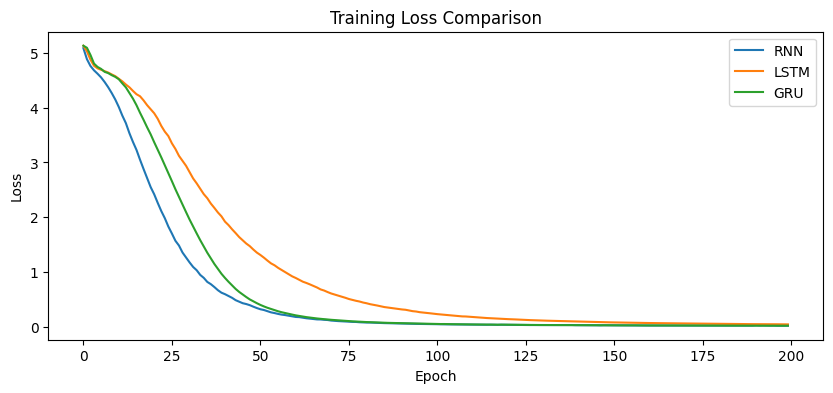

In [36]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

### Training Loss Comparison

The graph compares the training loss of the **RNN, LSTM, and GRU** models over **200 epochs**. For all three models, the loss decreases continuously as the number of epochs increases, which indicates that the models are successfully learning the patterns from the custom corpus.

From the graph, it can be observed that the **RNN** model reduces its loss more quickly during the initial training epochs. The **GRU** model also converges rapidly and performs similarly to the RNN. The **LSTM** model takes comparatively more epochs to reduce its loss but eventually converges to a very low loss value.

Overall, all three models achieve low training loss by the end of training, showing that they have effectively learned the sequence patterns from the dataset and are capable of generating meaningful text.


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [37]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [38]:
print("RNN :", generate_text(rnn_model, "Kalpana Baghel", 10))
print("LSTM:", generate_text(lstm_model, "Kalpana Baghel", 10))
print("GRU :", generate_text(gru_model, "Kalpana Baghel", 10))

RNN : Kalpana Baghel my life is full of chaos drama and enthusiasm i
LSTM: Kalpana Baghel my brain starts considering every possible feature every possible sitting
GRU : Kalpana Baghel my life is full of chaos drama and enthusiasm i


In [39]:
print("RNN :", generate_text(rnn_model, "Overfitting", 10))
print("LSTM:", generate_text(lstm_model, "Overfitting", 10))
print("GRU :", generate_text(gru_model, "Overfitting", 10))

RNN : Overfitting and nowadays i am trying to reduce this overthinking and
LSTM: Overfitting student at jk lakshmipat university jklu but that is not
GRU : Overfitting memories and enjoy the little moments that are often ignored


#Observation from Generate Text Samples
I tested the trained **RNN, LSTM, and GRU** models using two different seed phrases, **"Kalpana Baghel"** and **"Overfitting"**, to evaluate their text generation capability. The **RNN** and **GRU** models generated text that closely matched the patterns present in the custom corpus. The **LSTM** model also generated meaningful words, although its continuation was comparatively less coherent than the RNN and GRU outputs. Overall, the generated text shows that all three models learned the sequence patterns from the training data, with RNN and GRU producing more contextually relevant results for the selected seed phrases.


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
